# Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles
This is the code for the paper entitled "[**Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles**](https://arxiv.org/pdf/1910.08635.pdf)" published in IEEE GlobeCom 2019.  
Authors: Li Yang (liyanghart@gmail.com), Abdallah Moubayed, Ismail Hamieh, and Abdallah Shami  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

If you find this repository useful in your research, please cite:  
L. Yang, A. Moubayed, I. Hamieh and A. Shami, "Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles," 2019 IEEE Global Communications Conference (GLOBECOM), 2019, pp. 1-6, doi: 10.1109/GLOBECOM38437.2019.9013892.  

## Import libraries

In [346]:
!pip install imbalanced-learn

In [347]:
import warnings
warnings.filterwarnings("ignore")

In [348]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance

## Read the sampled CICIDS2017 dataset
The CICIDS2017 dataset is publicly available at: https://www.unb.ca/cic/datasets/ids-2017.html  
Due to the large size of this dataset, the sampled subsets of CICIDS2017 is used. The subsets are in the "data" folder.  
If you want to use this code on other datasets (e.g., CAN-intrusion dataset), just change the dataset name and follow the same steps. The models in this code are generic models that can be used in any intrusion detection/network traffic datasets.

In [349]:
!git clone https://github.com/Western-OC2-Lab/Intrusion-Detection-System-Using-Machine-Learning.git

Cloning into 'Intrusion-Detection-System-Using-Machine-Learning'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 164 (delta 73), reused 50 (delta 49), pack-reused 84 (from 1)
Receiving objects: 100% (164/164), 19.86 MiB | 11.22 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [350]:
%cd Intrusion-Detection-System-Using-Machine-Learning

/content/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning/Intrusion-Detection-System-Using-Machine-Learning


In [351]:
#Read dataset
df = pd.read_csv('data/CICIDS2017_sample.csv')
# The results in this code is based on the original CICIDS2017 dataset. Please go to cell [10] if you work on the sampled dataset.

In [352]:
df

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,4,2,0,37,0,31,6,18.500000,17.677670,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,142377,46,62,1325,105855,570,0,28.804348,111.407285,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118873,23,28,1169,45025,570,0,50.826087,156.137367,2896,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,143577,43,55,1301,107289,570,0,30.255814,115.178969,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,143745,49,59,1331,110185,570,0,27.163265,108.067176,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56656,234,2,2,64,232,32,32,32.000000,0.000000,116,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
56657,133288,2,2,94,482,47,47,47.000000,0.000000,241,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
56658,11507694,5,4,450,3525,450,0,90.000000,201.246118,3525,...,32,893.0,0.0,893,893,6503640.0,0.0,6503640,6503640,DoS
56659,11507707,8,6,416,11632,416,0,52.000000,147.078211,5792,...,32,897.0,0.0,897,897,6503122.0,0.0,6503122,6503122,DoS


In [353]:
df.Label.value_counts()

,count
Label,
BENIGN,22731
DoS,19035
PortScan,7946
BruteForce,2767
WebAttack,2180
Bot,1966
Infiltration,36


### Data sampling
Due to the space limit of GitHub files, we sample a small-sized subset for model learning using random sampling

In [354]:
# Randomly sample instances from majority classes
df_minor = df[(df['Label']=='WebAttack')|(df['Label']=='Bot')|(df['Label']=='Infiltration')]
df_BENIGN = df[(df['Label']=='BENIGN')]
df_BENIGN = df_BENIGN.sample(n=None, frac=0.01, replace=False, weights=None, random_state=None, axis=0)
df_DoS = df[(df['Label']=='DoS')]
df_DoS = df_DoS.sample(n=None, frac=0.05, replace=False, weights=None, random_state=None, axis=0)
df_PortScan = df[(df['Label']=='PortScan')]
df_PortScan = df_PortScan.sample(n=None, frac=0.05, replace=False, weights=None, random_state=None, axis=0)
df_BruteForce = df[(df['Label']=='BruteForce')]
df_BruteForce = df_BruteForce.sample(n=None, frac=0.2, replace=False, weights=None, random_state=None, axis=0)

In [355]:
df_s = pd.concat([df_BENIGN, df_DoS, df_PortScan, df_BruteForce, df_minor])

In [356]:
df_s = df_s.sort_index()

In [357]:
# Save the sampled dataset
df_s.to_csv('/content/CICIDS2017_sample.csv',index=0)

### Preprocessing (normalization and padding values)

In [358]:
df = pd.read_csv('/content/CICIDS2017_sample.csv')

In [359]:
# Min-max normalization (Label ko exclude karna hai)
numeric_features = df.drop(['Label'], axis=1).columns

df[numeric_features] = df[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

df = df.fillna(0)

In [360]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
df['Label'] = labelencoder.fit_transform(df['Label'])

### split train set and test set

In [361]:
X = df.drop(['Label'], axis=1).values
y = df['Label'].values   # reshape mat karo

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    test_size=0.2,
    random_state=0,
    stratify=y
)

In [362]:
X_train.shape

(5048, 77)

In [363]:
pd.Series(y_train).value_counts()

,count
6,1744
1,1573
3,761
2,442
5,317
0,182
4,29


In [364]:
print("y_train unique values:", np.unique(y_train))
print("y_train dtype:", y_train.dtype)

y_train unique values: [0 1 2 3 4 5 6]
y_train dtype: int64


In [365]:
print("dtype:", y_train.dtype)
print("unique:", np.unique(y_train))

dtype: int64
unique: [0 1 2 3 4 5 6]


In [366]:
print(np.unique(y_train))
print(y_train.dtype)

[0 1 2 3 4 5 6]
int64


In [367]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

### Oversampling by SMOTE

In [368]:
print("Shape:", y_train.shape)
print("Dtype:", y_train.dtype)
print("Unique values:", np.unique(y_train))
print("First 10:", y_train[:10])

Shape: (5048,)
Dtype: int64
Unique values: [0 1 2 3 4 5 6]
First 10: [1 6 3 6 2 6 3 3 6 3]


In [369]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
df['Label'] = labelencoder.fit_transform(df['Label'])

In [370]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [371]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [372]:
pd.Series(y_train).value_counts()

,count
1,1744
6,1744
3,1744
2,1744
5,1744
0,1744
4,1744


## Machine learning model training

### Training four base learners: decision tree, random forest, extra trees, XGBoost

Accuracy of DT: 0.9873317498020586
Precision of DT: 0.9873833338352661
Recall of DT: 0.9873317498020586
F1-score of DT: 0.98732400585556
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        45
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       111
           3       0.99      0.99      0.99       191
           4       0.62      0.71      0.67         7
           5       1.00      1.00      1.00        80
           6       1.00      1.00      1.00       436

    accuracy                           0.99      1263
   macro avg       0.92      0.93      0.92      1263
weighted avg       0.99      0.99      0.99      1263



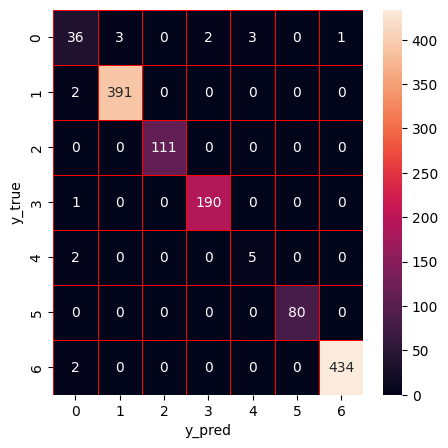

In [373]:
# Decision tree training and prediction
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train)
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [374]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

Accuracy of RF: 0.9881235154394299
Precision of RF: 0.9881321079441656
Recall of RF: 0.9881235154394299
F1-score of RF: 0.9880955015981107
              precision    recall  f1-score   support

           0       0.83      0.84      0.84        45
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       111
           3       0.99      1.00      1.00       191
           4       0.83      0.71      0.77         7
           5       1.00      1.00      1.00        80
           6       1.00      0.99      0.99       436

    accuracy                           0.99      1263
   macro avg       0.95      0.93      0.94      1263
weighted avg       0.99      0.99      0.99      1263



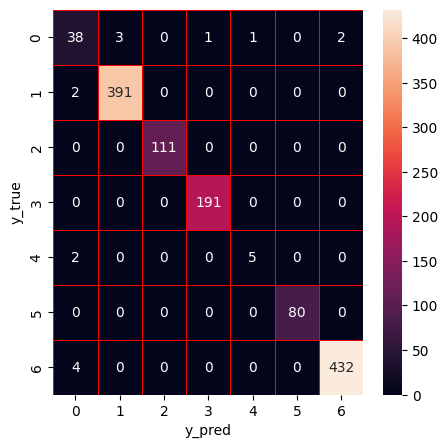

In [375]:
# Random Forest training and prediction
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train)
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [376]:
# ==============================
# 🔥 Save Final Model
# ==============================

import joblib

joblib.dump(rf, "ids_model.pkl")
joblib.dump(labelencoder, "label_encoder.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [377]:
# ==============================
# 🔥 Cross Validation Added
# ==============================

from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(random_state=0)

scores = cross_val_score(rf_cv, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.99049881 0.97860539 0.98969889 0.98732171 0.98335975]
Average CV Score: 0.9858969098554118


In [378]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

Accuracy of ET: 0.9873317498020586
Precision of ET: 0.987287470169499
Recall of ET: 0.9873317498020586
F1-score of ET: 0.9872008470544361
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        45
           1       0.99      0.99      0.99       393
           2       0.95      1.00      0.97       111
           3       1.00      1.00      1.00       191
           4       0.83      0.71      0.77         7
           5       1.00      1.00      1.00        80
           6       1.00      0.99      0.99       436

    accuracy                           0.99      1263
   macro avg       0.95      0.94      0.94      1263
weighted avg       0.99      0.99      0.99      1263



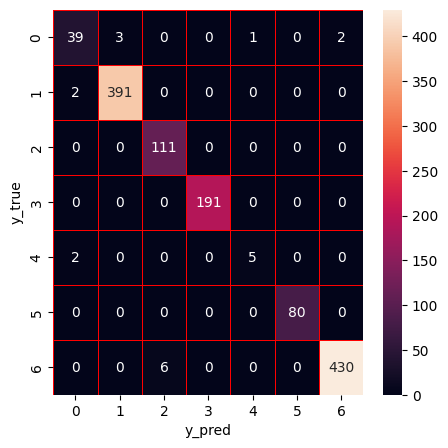

In [379]:
# Extra trees training and prediction
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train)
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [380]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

Accuracy of XGBoost: 0.9857482185273159
Precision of XGBoost: 0.9863659794559961
Recall of XGBoost: 0.9857482185273159
F1-score of XGBoost: 0.9860094474386297
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        45
           1       0.99      0.99      0.99       393
           2       0.99      1.00      1.00       111
           3       1.00      0.98      0.99       191
           4       0.62      0.71      0.67         7
           5       1.00      1.00      1.00        80
           6       1.00      0.99      0.99       436

    accuracy                           0.99      1263
   macro avg       0.92      0.93      0.92      1263
weighted avg       0.99      0.99      0.99      1263



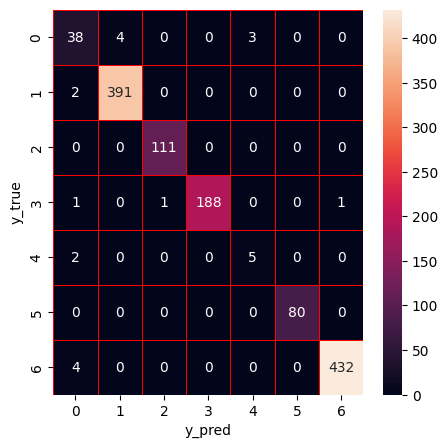

In [381]:
# XGboost training and prediction
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

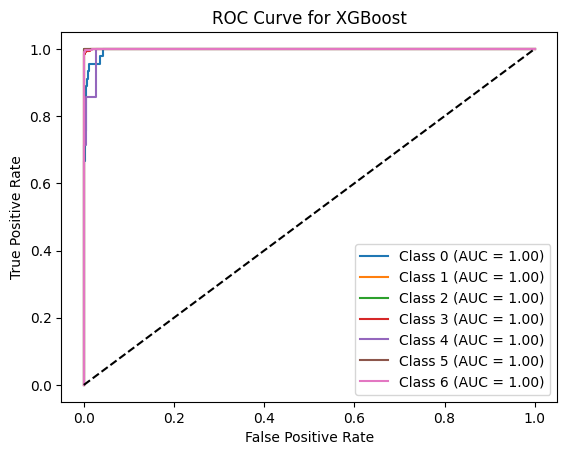

In [382]:
# ==============================
# 🔥 ROC Curve for XGBoost
# ==============================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = xg.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(np.unique(y))):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(np.unique(y))):
    plt.plot(fpr[i], tpr[i], label='Class %d (AUC = %0.2f)' % (i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend()
plt.show()

In [383]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

In [384]:
# ==============================
# 🔥 Hyperparameter Tuning (GridSearch)
# ==============================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
}

grid = GridSearchCV(RandomForestClassifier(random_state=0),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV Score: 0.9968873742036681


### Stacking model construction (ensemble for 4 base learners)

In [385]:
# Use the outputs of 4 base models to construct a new ensemble model
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,1,1,1,1
1,6,6,6,6
2,3,3,3,3
3,6,6,6,6
4,2,2,2,2


In [386]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [387]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

In [388]:
stk = xgb.XGBClassifier().fit(x_train, y_train)

Accuracy of Stacking: 0.9873317498020586
Precision of Stacking: 0.9873833338352661
Recall of Stacking: 0.9873317498020586
F1-score of Stacking: 0.98732400585556
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        45
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       111
           3       0.99      0.99      0.99       191
           4       0.62      0.71      0.67         7
           5       1.00      1.00      1.00        80
           6       1.00      1.00      1.00       436

    accuracy                           0.99      1263
   macro avg       0.92      0.93      0.92      1263
weighted avg       0.99      0.99      0.99      1263



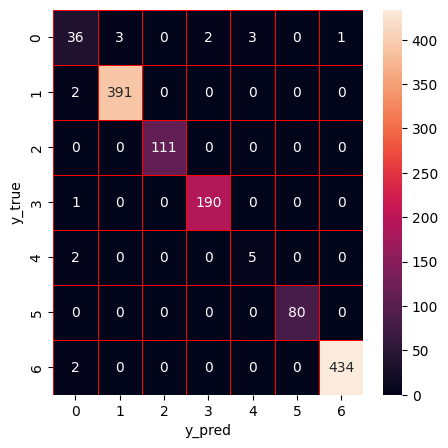

In [389]:
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

## Feature Selection

### Feature importance

In [390]:
# Save the feature importance lists generated by four tree-based algorithms
dt_feature = dt.feature_importances_
rf_feature = rf.feature_importances_
et_feature = et.feature_importances_
xgb_feature = xg.feature_importances_

In [391]:
# calculate the average importance value of each feature
avg_feature = (dt_feature + rf_feature + et_feature + xgb_feature)/4

In [392]:
feature=(df.drop(['Label'],axis=1)).columns.values
print ("Features sorted by their score:")
print (sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True))

Features sorted by their score:
[(np.float64(0.0834), 'Init_Win_bytes_backward'), (np.float64(0.0833), 'Fwd Packet Length Max'), (np.float64(0.0567), 'Total Length of Fwd Packets'), (np.float64(0.0456), 'Bwd Packet Length Min'), (np.float64(0.0397), 'min_seg_size_forward'), (np.float64(0.039), 'Bwd Packet Length Std'), (np.float64(0.0365), 'PSH Flag Count'), (np.float64(0.0364), 'Min Packet Length'), (np.float64(0.0324), 'Init_Win_bytes_forward'), (np.float64(0.0323), 'Bwd Packets/s'), (np.float64(0.031), 'act_data_pkt_fwd'), (np.float64(0.026), 'Fwd IAT Max'), (np.float64(0.0222), 'Fwd IAT Total'), (np.float64(0.0212), 'Average Packet Size'), (np.float64(0.0186), 'Total Fwd Packets'), (np.float64(0.0182), 'Flow Duration'), (np.float64(0.0159), 'Bwd Packet Length Mean'), (np.float64(0.0157), 'Fwd PSH Flags'), (np.float64(0.0154), 'Fwd Header Length'), (np.float64(0.015), 'Fwd Packet Length Std'), (np.float64(0.0148), 'Packet Length Variance'), (np.float64(0.0133), 'Flow IAT Max'), (np.

In [393]:
f_list = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)

In [394]:
len(f_list)

77

In [395]:
# Select the important features from top-importance to bottom-importance until the accumulated importance reaches 0.9 (out of 1)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])
    if Sum>=0.9:
        break

In [396]:
X_fs = df[fs].values

In [397]:
# ==============================
# 🔥 PCA Comparison
# ==============================

from sklearn.decomposition import PCA

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=0, stratify=y
)

rf_pca = RandomForestClassifier(random_state=0)
rf_pca.fit(X_train_pca, y_train_pca)

print("Accuracy with PCA:", rf_pca.score(X_test_pca, y_test_pca))

Accuracy with PCA: 0.9865399841646872


In [398]:
X_train, X_test, y_train, y_test = train_test_split(X_fs,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [399]:
X_train.shape

(5048, 42)

In [400]:
pd.Series(y_train).value_counts()

,count
6,1744
1,1573
3,761
2,442
5,317
0,182
4,29


### Oversampling by SMOTE

In [401]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [402]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [403]:
pd.Series(y_train).value_counts()

,count
1,1744
6,1744
3,1744
2,1744
5,1744
0,1744
4,1744


## Machine learning model training after feature selection

Accuracy of DT: 0.9849564528899446
Precision of DT: 0.9859812587218608
Recall of DT: 0.9849564528899446
F1-score of DT: 0.9853968264772369
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        45
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       111
           3       0.99      0.99      0.99       191
           4       0.56      0.71      0.62         7
           5       1.00      1.00      1.00        80
           6       1.00      0.99      0.99       436

    accuracy                           0.98      1263
   macro avg       0.90      0.93      0.92      1263
weighted avg       0.99      0.98      0.99      1263



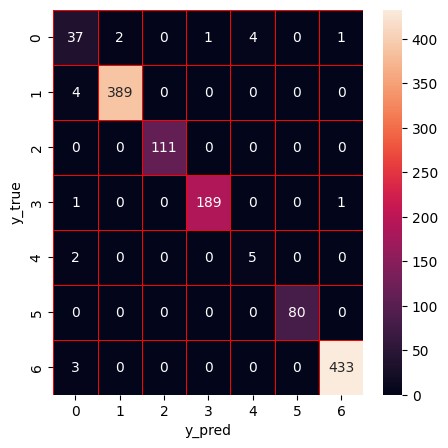

In [404]:
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train)
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [405]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

Accuracy of RF: 0.9912905779889153
Precision of RF: 0.9913649784995193
Recall of RF: 0.9912905779889153
F1-score of RF: 0.9912853944279247
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        45
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       111
           3       1.00      0.99      1.00       191
           4       0.83      0.71      0.77         7
           5       1.00      1.00      1.00        80
           6       1.00      1.00      1.00       436

    accuracy                           0.99      1263
   macro avg       0.96      0.94      0.95      1263
weighted avg       0.99      0.99      0.99      1263



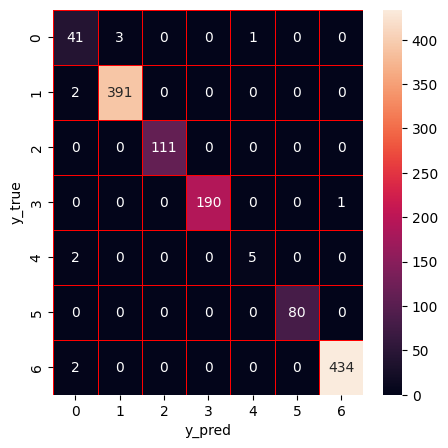

In [406]:
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train) # modelin veri üzerinde öğrenmesi fit fonksiyonuyla yapılıyor
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [407]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(random_state=0)

scores = cross_val_score(rf_cv, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.99049881 0.97860539 0.98969889 0.98732171 0.98335975]
Average CV Score: 0.9858969098554118


In [408]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

Accuracy of ET: 0.9897070467141726
Precision of ET: 0.9896246292755821
Recall of ET: 0.9897070467141726
F1-score of ET: 0.9896317834958753
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        45
           1       0.99      0.99      0.99       393
           2       0.97      1.00      0.99       111
           3       1.00      1.00      1.00       191
           4       0.71      0.71      0.71         7
           5       1.00      1.00      1.00        80
           6       1.00      0.99      1.00       436

    accuracy                           0.99      1263
   macro avg       0.94      0.94      0.94      1263
weighted avg       0.99      0.99      0.99      1263



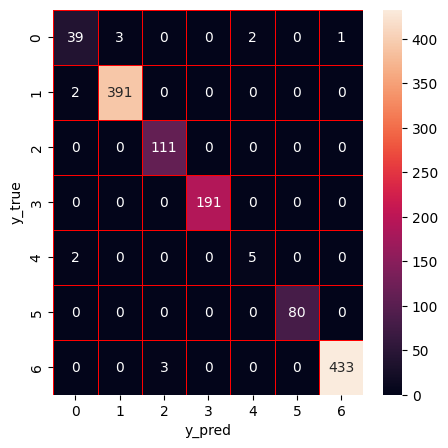

In [409]:
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train)
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [410]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

Accuracy of XGBoost: 0.9865399841646872
Precision of XGBoost: 0.9872425071355702
Recall of XGBoost: 0.9865399841646872
F1-score of XGBoost: 0.9868329119021331
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        45
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       111
           3       1.00      0.99      1.00       191
           4       0.56      0.71      0.62         7
           5       1.00      1.00      1.00        80
           6       1.00      0.99      0.99       436

    accuracy                           0.99      1263
   macro avg       0.91      0.93      0.92      1263
weighted avg       0.99      0.99      0.99      1263



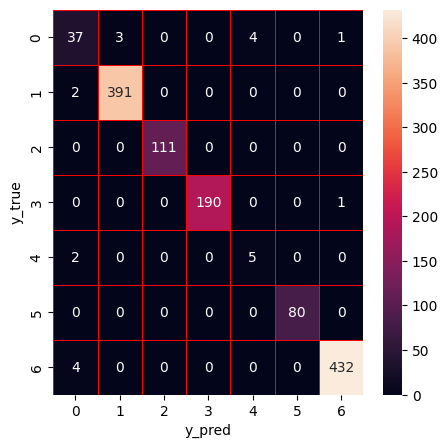

In [411]:
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

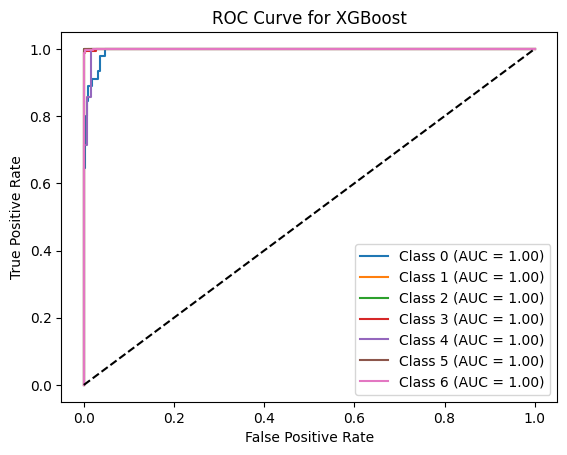

In [412]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.unique(y))

# Probability prediction
y_score = xg.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(np.unique(y))):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(np.unique(y))):
    plt.plot(fpr[i], tpr[i], label='Class %d (AUC = %0.2f)' % (i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend()
plt.show()

In [413]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

### Stacking model construction

In [414]:
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,1,1,1,1
1,6,6,6,6
2,3,3,3,3
3,6,6,6,6
4,2,2,2,2


In [415]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [416]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

Accuracy of Stacking: 0.9849564528899446
Precision of Stacking: 0.9859812587218608
Recall of Stacking: 0.9849564528899446
F1-score of Stacking: 0.9853968264772369
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        45
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       111
           3       0.99      0.99      0.99       191
           4       0.56      0.71      0.62         7
           5       1.00      1.00      1.00        80
           6       1.00      0.99      0.99       436

    accuracy                           0.98      1263
   macro avg       0.90      0.93      0.92      1263
weighted avg       0.99      0.98      0.99      1263



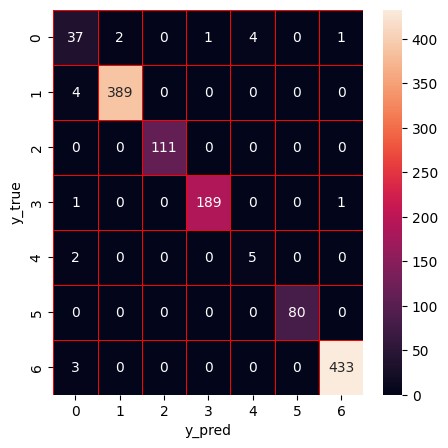

In [417]:
stk = xgb.XGBClassifier().fit(x_train, y_train)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()